# Лабораторна робота №4
## Основи нейронних мереж: побудова та навчання перцептрона
### Датасет: Lung Cancer (Варіант 8)

## 1. Імпорт бібліотек та завантаження даних

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_curve, auc, f1_score, precision_score, recall_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Відтворюваність результатів
torch.manual_seed(42)
np.random.seed(42)

print('Усі бібліотеки успішно імпортовані')
print(f'PyTorch version: {torch.__version__}')

Усі бібліотеки успішно імпортовані
PyTorch version: 2.6.0+cu124


In [2]:
# Завантаження датасету
data = pd.read_csv('variant8-lung-cancer.csv')
print('Форма датасету:', data.shape)
print('\nПерші 5 рядків:')
data.head()

Форма датасету: (309, 16)

Перші 5 рядків:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [3]:
print('Інформація про датасет:')
print(data.info())
print('\nРозподіл класів:')
print(data['LUNG_CANCER'].value_counts())
print('\nСтатистика:')
data.describe()

Інформація про датасет:
<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


## 2. Аналіз прикладів з завдання

### PyTorch (MLP) приклад:
- **Архітектура**: 2 шари (input→hidden→output), hidden_size=8
- **Активаційні функції**: ReLU у прихованому шарі, Sigmoid на виході
- **Функція втрат**: BCELoss (Binary Cross-Entropy)
- **Оптимізатор**: Adam, lr=0.001

### NumPy (XOR) приклад:
- **Архітектура**: input(2)→hidden(4)→output(1)
- **Активаційні функції**: ReLU у прихованому шарі, Sigmoid на виході
- **Функція втрат**: Binary Cross-Entropy (реалізована вручну)
- **Оптимізатор**: Gradient Descent (реалізований вручну)

### Порівняння:
**PyTorch реалізація є кращою**, оскільки:
1. Автоматичне обчислення градієнтів (autograd) — менше ручного коду
2. Простота розширення: додати шар = 1 рядок
3. Оптимізатор Adam значно краще збігається ніж базовий GD
4. Підтримка GPU без змін у коді
5. Готові модулі BatchNorm, Dropout, Schedulers

## 3. Підготовка даних

In [4]:
# Кодування категоріальних ознак
df = data.copy()

# GENDER: M=1, F=0
df['GENDER'] = (df['GENDER'] == 'M').astype(int)

# LUNG_CANCER: YES=1, NO=0
df['LUNG_CANCER'] = (df['LUNG_CANCER'] == 'YES').astype(int)

# Видалення пробілів у назвах колонок
df.columns = df.columns.str.strip()

# Розділення на X та y
X = df.drop(columns=['LUNG_CANCER']).values
y = df['LUNG_CANCER'].values

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Позитивний клас (рак):', y.sum(), f'({y.mean()*100:.1f}%)')
print('Негативний клас (норма):', (1-y).sum(), f'({(1-y).mean()*100:.1f}%)')

X shape: (309, 15)
y shape: (309,)
Позитивний клас (рак): 270 (87.4%)
Негативний клас (норма): 39 (12.6%)


In [5]:
# Нормалізація ознак
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Розділення на train/val/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# Перетворення у тензори
def to_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    )

X_train_t, y_train_t = to_tensors(X_train, y_train)
X_val_t,   y_val_t   = to_tensors(X_val,   y_val)
X_test_t,  y_test_t  = to_tensors(X_test,  y_test)

# DataLoader для мінібатч-навчання
BATCH_SIZE = 32
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=BATCH_SIZE
)

INPUT_SIZE = X_train.shape[1]
print(f'\nКількість ознак: {INPUT_SIZE}')

Train: 222 | Val: 40 | Test: 47

Кількість ознак: 15


## 4. Глибока архітектура (≥4 прихованих шари, BatchNorm, Dropout)

In [6]:
class DeepMLP(nn.Module):
    """
    Глибокий MLP для бінарної класифікації.
    Містить 4 приховані шари з BatchNorm та Dropout.
    """
    def __init__(self, input_size, dropout_rate=0.3):
        super(DeepMLP, self).__init__()
        
        self.network = nn.Sequential(
            # Шар 1
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Шар 2
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Шар 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Шар 4
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # Вихідний шар
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)


# Перевірка архітектури
model_test = DeepMLP(INPUT_SIZE)
print(model_test)
total_params = sum(p.numel() for p in model_test.parameters())
print(f'\nЗагальна кількість параметрів: {total_params:,}')

DeepMLP(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.3, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
    (17): Sigmoid()
  )
)

Загальна кількість параметрів: 20,289


## 5. Функція навчання з Early Stopping та Scheduler

In [7]:
def train_model(
    model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=150,
    patience=15,
    l1_lambda=0.0,
    scheduler=None,
    model_name='model'
):
    """
    Навчає модель з Early Stopping, опційною L1-регуляризацією та LR scheduler.
    Повертає словник з метриками по епохам.
    """
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # ── Навчання ──────────────────────────────────
        model.train()
        train_losses, train_preds, train_labels = [], [], []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # L1 регуляризація
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm
            
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (outputs.detach() > 0.5).float()
            train_preds.extend(preds.numpy())
            train_labels.extend(y_batch.numpy())
        
        # ── Валідація ─────────────────────────────────
        model.eval()
        val_losses, val_preds, val_labels = [], [], []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                preds = (outputs > 0.5).float()
                val_preds.extend(preds.numpy())
                val_labels.extend(y_batch.numpy())
        
        # Метрики епохи
        avg_train_loss = np.mean(train_losses)
        avg_val_loss   = np.mean(val_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc   = accuracy_score(val_labels,   val_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        # LR Scheduler
        if scheduler is not None:
            scheduler.step(avg_val_loss)
        
        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d} | '
                  f'Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | '
                  f'Val Acc: {val_acc*100:.1f}%')
        
        if patience_counter >= patience:
            print(f'  → Early stopping на епосі {epoch+1}')
            break
    
    # Відновлення найкращих ваг
    if best_weights:
        model.load_state_dict(best_weights)
    
    return history


def evaluate_model(model, X_tensor, y_tensor, label='Test'):
    """Повна оцінка моделі: accuracy, f1, precision, recall + ROC."""
    model.eval()
    with torch.no_grad():
        probs = model(X_tensor).numpy()
    
    preds = (probs > 0.5).astype(int).flatten()
    y_true = y_tensor.numpy().flatten()
    
    acc  = accuracy_score(y_true, preds)
    f1   = f1_score(y_true, preds)
    prec = precision_score(y_true, preds)
    rec  = recall_score(y_true, preds)
    
    fpr, tpr, _ = roc_curve(y_true, probs.flatten())
    roc_auc = auc(fpr, tpr)
    
    print(f'\n── {label} ──────────────────────────────────')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(classification_report(y_true, preds, target_names=['No Cancer', 'Cancer']))
    
    return dict(acc=acc, f1=f1, precision=prec, recall=rec, auc=roc_auc,
                fpr=fpr, tpr=tpr)


def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'],   label='Val Loss', linestyle='--')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train Accuracy')
    axes[1].plot(history['val_acc'],   label='Val Accuracy', linestyle='--')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print('Допоміжні функції визначено.')

Допоміжні функції визначено.


## 6. Порівняння оптимізаторів: Adam vs SGD vs RMSprop


═══ Оптимізатор: Adam ═══
[Adam] Epoch  20 | Train Loss: 0.3449 | Val Loss: 0.4177 | Val Acc: 90.0%
[Adam] Epoch  40 | Train Loss: 0.2051 | Val Loss: 0.3845 | Val Acc: 85.0%
  → Early stopping на епосі 54

── Adam (Test) ──────────────────────────────────
  Accuracy : 89.36%
  F1 Score : 0.9351
  Precision: 1.0000
  Recall   : 0.8780
  ROC-AUC  : 0.9146
              precision    recall  f1-score   support

   No Cancer       0.55      1.00      0.71         6
      Cancer       1.00      0.88      0.94        41

    accuracy                           0.89        47
   macro avg       0.77      0.94      0.82        47
weighted avg       0.94      0.89      0.91        47



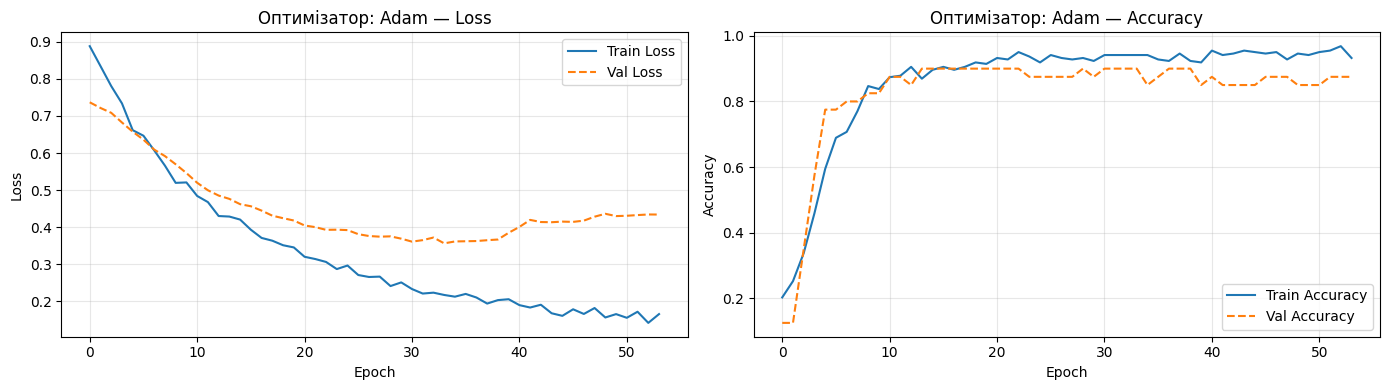


═══ Оптимізатор: SGD ═══
[SGD] Epoch  20 | Train Loss: 0.2324 | Val Loss: 0.3535 | Val Acc: 87.5%
[SGD] Epoch  40 | Train Loss: 0.1665 | Val Loss: 0.3863 | Val Acc: 87.5%
  → Early stopping на епосі 47

── SGD (Test) ──────────────────────────────────
  Accuracy : 87.23%
  F1 Score : 0.9250
  Precision: 0.9487
  Recall   : 0.9024
  ROC-AUC  : 0.8780
              precision    recall  f1-score   support

   No Cancer       0.50      0.67      0.57         6
      Cancer       0.95      0.90      0.93        41

    accuracy                           0.87        47
   macro avg       0.72      0.78      0.75        47
weighted avg       0.89      0.87      0.88        47



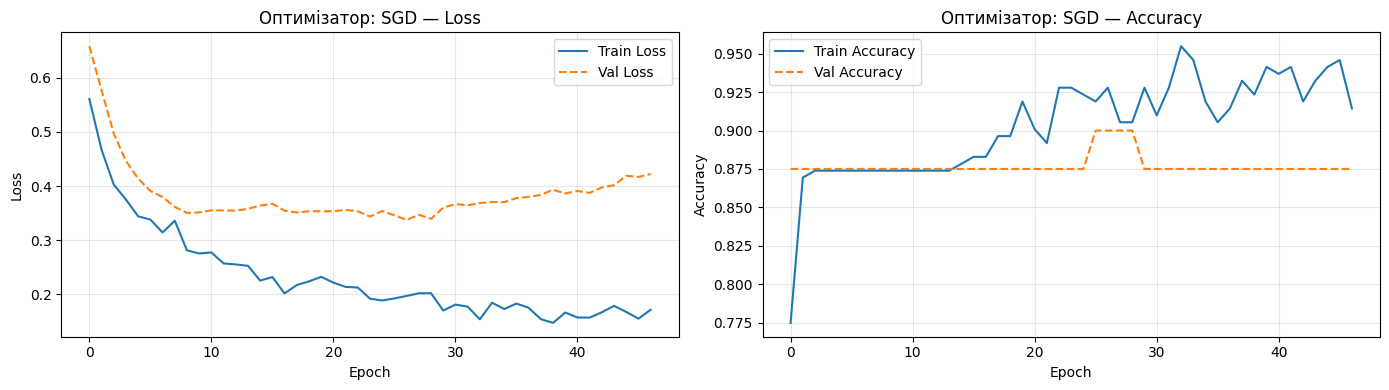


═══ Оптимізатор: RMSprop ═══
[RMSprop] Epoch  20 | Train Loss: 0.1616 | Val Loss: 0.3911 | Val Acc: 87.5%
  → Early stopping на епосі 33

── RMSprop (Test) ──────────────────────────────────
  Accuracy : 89.36%
  F1 Score : 0.9367
  Precision: 0.9737
  Recall   : 0.9024
  ROC-AUC  : 0.8659
              precision    recall  f1-score   support

   No Cancer       0.56      0.83      0.67         6
      Cancer       0.97      0.90      0.94        41

    accuracy                           0.89        47
   macro avg       0.76      0.87      0.80        47
weighted avg       0.92      0.89      0.90        47



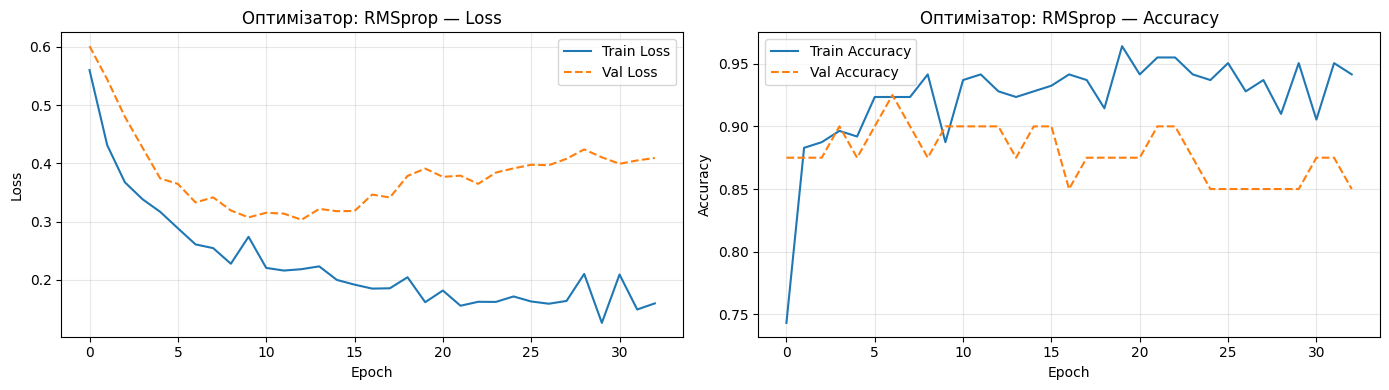

In [8]:
criterion = nn.BCELoss()
optimizer_configs = [
    ('Adam',    lambda p: optim.Adam(p,    lr=0.001)),
    ('SGD',     lambda p: optim.SGD(p,     lr=0.01, momentum=0.9)),
    ('RMSprop', lambda p: optim.RMSprop(p, lr=0.001, alpha=0.99)),
]

optimizer_results = {}

for name, opt_fn in optimizer_configs:
    print(f'\n═══ Оптимізатор: {name} ═══')
    model = DeepMLP(INPUT_SIZE, dropout_rate=0.3)
    optimizer = opt_fn(model.parameters())
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=7
    )
    history = train_model(
        model, optimizer, criterion,
        train_loader, val_loader,
        num_epochs=150, patience=20,
        scheduler=scheduler,
        model_name=name
    )
    metrics = evaluate_model(model, X_test_t, y_test_t, label=f'{name} (Test)')
    optimizer_results[name] = {'model': model, 'history': history, 'metrics': metrics}
    plot_history(history, title=f'Оптимізатор: {name}')

In [9]:
# Порівняння оптимізаторів — зведена таблиця
print('\n╔══════════════════════════════════════════════════════════╗')
print(f'║  {"Оптимізатор":<12} | {"Accuracy":>9} | {"F1":>7} | {"ROC-AUC":>8} ║')
print('╠══════════════════════════════════════════════════════════╣')
for name, res in optimizer_results.items():
    m = res['metrics']
    print(f'║  {name:<12} | {m["acc"]*100:>8.2f}% | {m["f1"]:>7.4f} | {m["auc"]:>8.4f} ║')
print('╚══════════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════════╗
║  Оптимізатор  |  Accuracy |      F1 |  ROC-AUC ║
╠══════════════════════════════════════════════════════════╣
║  Adam         |    89.36% |  0.9351 |   0.9146 ║
║  SGD          |    87.23% |  0.9250 |   0.8780 ║
║  RMSprop      |    89.36% |  0.9367 |   0.8659 ║
╚══════════════════════════════════════════════════════════╝


## 7. Порівняння методів регуляризації: без / L1 / L2 / Dropout+BN


═══ Регуляризація: Без регуляризації ═══
[Без регуляризації] Epoch  20 | Train Loss: 0.0571 | Val Loss: 0.9439 | Val Acc: 85.0%
  → Early stopping на епосі 28

── Без регуляризації ──────────────────────────────────
  Accuracy : 87.23%
  F1 Score : 0.9318
  Precision: 0.8723
  Recall   : 1.0000
  ROC-AUC  : 0.8862
              precision    recall  f1-score   support

   No Cancer       0.00      0.00      0.00         6
      Cancer       0.87      1.00      0.93        41

    accuracy                           0.87        47
   macro avg       0.44      0.50      0.47        47
weighted avg       0.76      0.87      0.81        47



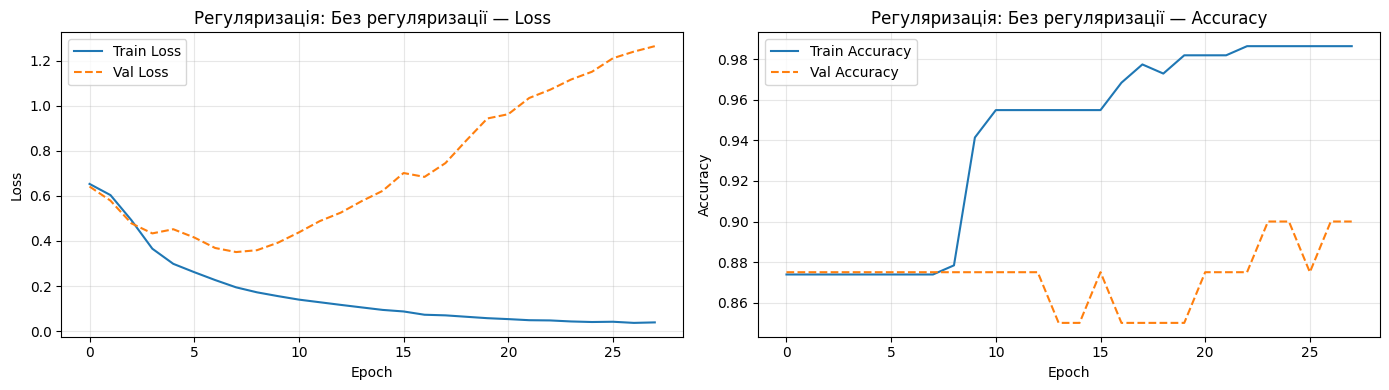


═══ Регуляризація: L1 (λ=1e-4) ═══
[L1 (λ=1e-4)] Epoch  20 | Train Loss: 0.1842 | Val Loss: 0.4579 | Val Acc: 90.0%
  → Early stopping на епосі 31

── L1 (λ=1e-4) ──────────────────────────────────
  Accuracy : 87.23%
  F1 Score : 0.9318
  Precision: 0.8723
  Recall   : 1.0000
  ROC-AUC  : 0.9228
              precision    recall  f1-score   support

   No Cancer       0.00      0.00      0.00         6
      Cancer       0.87      1.00      0.93        41

    accuracy                           0.87        47
   macro avg       0.44      0.50      0.47        47
weighted avg       0.76      0.87      0.81        47



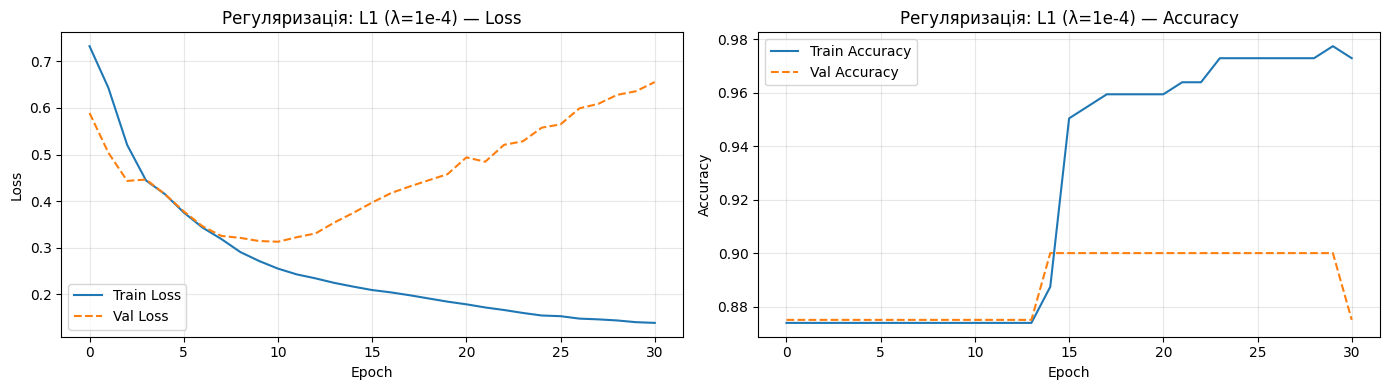


═══ Регуляризація: L2 (wd=1e-4) ═══
[L2 (wd=1e-4)] Epoch  20 | Train Loss: 0.0646 | Val Loss: 0.7692 | Val Acc: 87.5%
  → Early stopping на епосі 28

── L2 (wd=1e-4) ──────────────────────────────────
  Accuracy : 87.23%
  F1 Score : 0.9318
  Precision: 0.8723
  Recall   : 1.0000
  ROC-AUC  : 0.8171
              precision    recall  f1-score   support

   No Cancer       0.00      0.00      0.00         6
      Cancer       0.87      1.00      0.93        41

    accuracy                           0.87        47
   macro avg       0.44      0.50      0.47        47
weighted avg       0.76      0.87      0.81        47



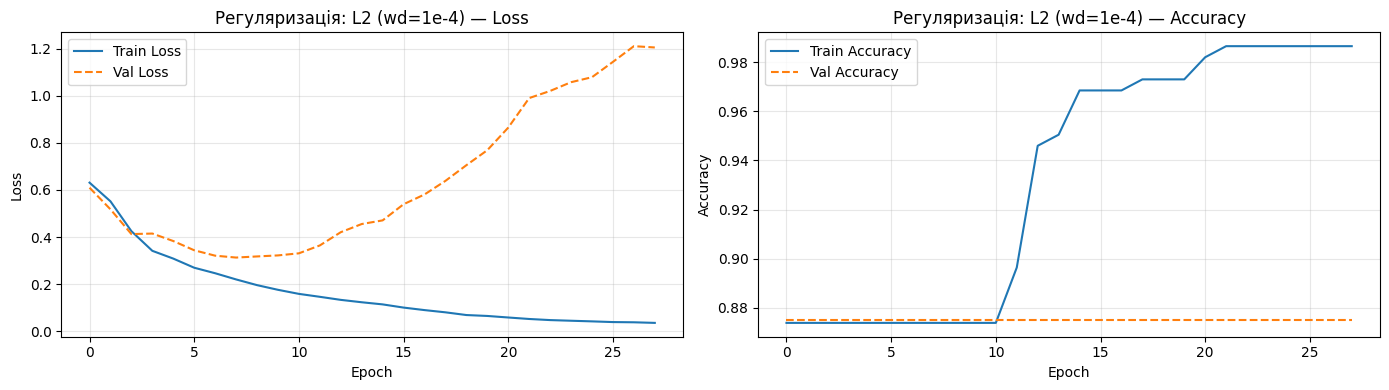


═══ Регуляризація: Dropout+BatchNorm ═══
[Dropout+BatchNorm] Epoch  20 | Train Loss: 0.2320 | Val Loss: 0.3366 | Val Acc: 87.5%
  → Early stopping на епосі 37

── Dropout+BatchNorm ──────────────────────────────────
  Accuracy : 85.11%
  F1 Score : 0.9114
  Precision: 0.9474
  Recall   : 0.8780
  ROC-AUC  : 0.8780
              precision    recall  f1-score   support

   No Cancer       0.44      0.67      0.53         6
      Cancer       0.95      0.88      0.91        41

    accuracy                           0.85        47
   macro avg       0.70      0.77      0.72        47
weighted avg       0.88      0.85      0.86        47



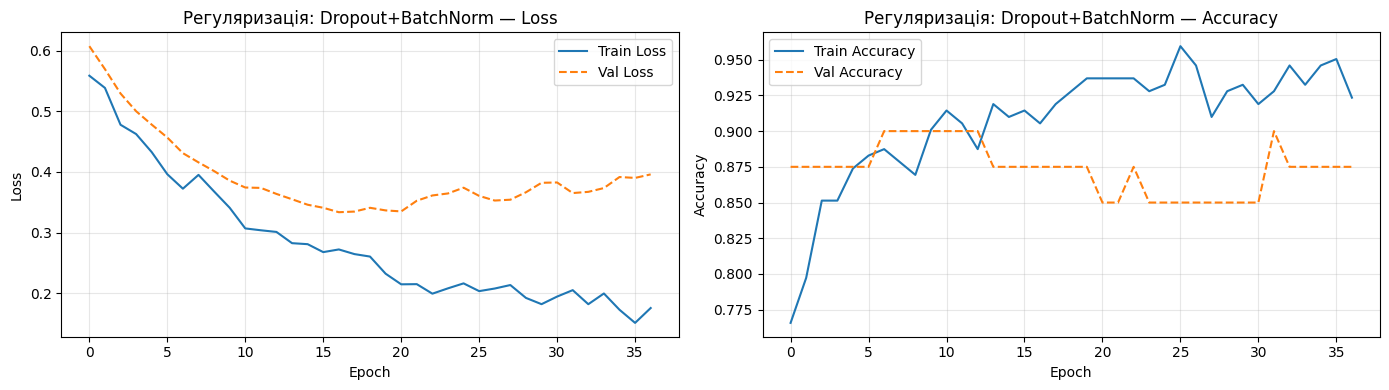

In [10]:
class SimpleMLP(nn.Module):
    """Простий MLP без регуляризації для базового порівняння."""
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(),
            nn.Linear(64, 128),        nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


reg_configs = [
    {'name': 'Без регуляризації', 'model_cls': SimpleMLP, 'l1': 0.0, 'wd': 0.0},
    {'name': 'L1 (λ=1e-4)',       'model_cls': SimpleMLP, 'l1': 1e-4, 'wd': 0.0},
    {'name': 'L2 (wd=1e-4)',       'model_cls': SimpleMLP, 'l1': 0.0, 'wd': 1e-4},
    {'name': 'Dropout+BatchNorm',  'model_cls': DeepMLP,   'l1': 0.0, 'wd': 0.0},
]

reg_results = {}

for cfg in reg_configs:
    name = cfg['name']
    print(f'\n═══ Регуляризація: {name} ═══')
    model = cfg['model_cls'](INPUT_SIZE)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=cfg['wd'])
    history = train_model(
        model, optimizer, criterion,
        train_loader, val_loader,
        num_epochs=150, patience=20,
        l1_lambda=cfg['l1'],
        model_name=name
    )
    metrics = evaluate_model(model, X_test_t, y_test_t, label=name)
    
    # Аналіз ваг
    all_weights = torch.cat([p.data.flatten() for p in model.parameters()])
    reg_results[name] = {
        'model': model, 'history': history, 'metrics': metrics,
        'mean_abs_weight': all_weights.abs().mean().item(),
        'zero_weights_pct': (all_weights.abs() < 1e-4).float().mean().item() * 100
    }
    plot_history(history, title=f'Регуляризація: {name}')

In [11]:
# Порівняння регуляризацій
print('\n╔═══════════════════════════════════════════════════════════════════════════════╗')
print(f'║  {"Метод":<22} | {"Acc":>8} | {"F1":>7} | {"AUC":>7} | {"|w| mean":>9} | ≈0-ваг ║')
print('╠═══════════════════════════════════════════════════════════════════════════════╣')
for name, res in reg_results.items():
    m = res['metrics']
    print(f'║  {name:<22} | {m["acc"]*100:>7.2f}% | {m["f1"]:>7.4f} | {m["auc"]:>7.4f} | {res["mean_abs_weight"]:>9.5f} | {res["zero_weights_pct"]:>4.1f}%  ║')
print('╚═══════════════════════════════════════════════════════════════════════════════╝')


╔═══════════════════════════════════════════════════════════════════════════════╗
║  Метод                  |      Acc |      F1 |     AUC |  |w| mean | ≈0-ваг ║
╠═══════════════════════════════════════════════════════════════════════════════╣
║  Без регуляризації      |   87.23% |  0.9318 |  0.8862 |   0.06165 |  0.1%  ║
║  L1 (λ=1e-4)            |   87.23% |  0.9318 |  0.9228 |   0.04285 |  4.2%  ║
║  L2 (wd=1e-4)           |   87.23% |  0.9318 |  0.8171 |   0.05639 |  0.4%  ║
║  Dropout+BatchNorm      |   85.11% |  0.9114 |  0.8780 |   0.07233 |  0.1%  ║
╚═══════════════════════════════════════════════════════════════════════════════╝


## 8. Дослідження overfitting: навчання без Early Stopping

═══ Навчання без Early Stopping (для демонстрації overfitting) ═══
[Overfit] Epoch  20 | Train Loss: 0.0670 | Val Loss: 0.8027 | Val Acc: 85.0%
[Overfit] Epoch  40 | Train Loss: 0.0119 | Val Loss: 1.5299 | Val Acc: 87.5%
[Overfit] Epoch  60 | Train Loss: 0.0078 | Val Loss: 6.8247 | Val Acc: 85.0%
[Overfit] Epoch  80 | Train Loss: 0.0078 | Val Loss: 6.8683 | Val Acc: 85.0%
[Overfit] Epoch 100 | Train Loss: 0.0061 | Val Loss: 8.1894 | Val Acc: 87.5%
[Overfit] Epoch 120 | Train Loss: 0.0029 | Val Loss: 8.2118 | Val Acc: 87.5%
[Overfit] Epoch 140 | Train Loss: 0.0021 | Val Loss: 8.2343 | Val Acc: 87.5%
[Overfit] Epoch 160 | Train Loss: 0.0007 | Val Loss: 8.2964 | Val Acc: 87.5%
[Overfit] Epoch 180 | Train Loss: 0.0007 | Val Loss: 8.3431 | Val Acc: 87.5%
[Overfit] Epoch 200 | Train Loss: 0.0003 | Val Loss: 8.3682 | Val Acc: 87.5%
[Overfit] Epoch 220 | Train Loss: 0.0002 | Val Loss: 8.3951 | Val Acc: 87.5%
[Overfit] Epoch 240 | Train Loss: 0.0001 | Val Loss: 8.4112 | Val Acc: 87.5%
[Overfit]

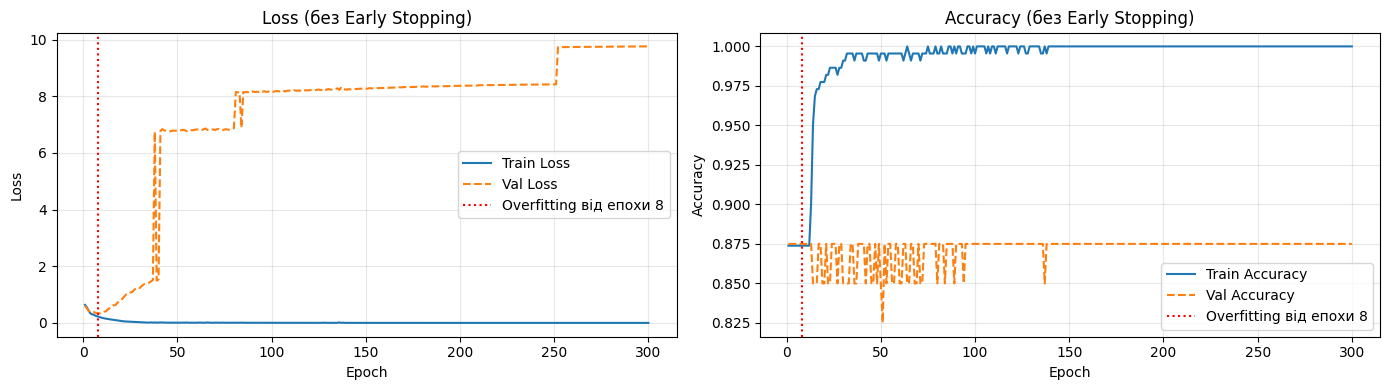

In [12]:
print('═══ Навчання без Early Stopping (для демонстрації overfitting) ═══')
overfit_model = SimpleMLP(INPUT_SIZE)
overfit_opt = optim.Adam(overfit_model.parameters(), lr=0.001)
overfit_history = train_model(
    overfit_model, overfit_opt, criterion,
    train_loader, val_loader,
    num_epochs=300,
    patience=999,  # вимкнути Early Stopping
    model_name='Overfit'
)

# Пошук моменту початку overfitting
val_losses = overfit_history['val_loss']
min_val_epoch = np.argmin(val_losses)
print(f'\nНайкраща Val Loss на епосі: {min_val_epoch+1}')
print(f'Після цього val_loss зростає → overfitting')

# Побудова графіків
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, len(overfit_history['train_loss'])+1)

axes[0].plot(epochs, overfit_history['train_loss'], label='Train Loss')
axes[0].plot(epochs, overfit_history['val_loss'],   label='Val Loss', linestyle='--')
axes[0].axvline(min_val_epoch+1, color='red', linestyle=':', label=f'Overfitting від епохи {min_val_epoch+1}')
axes[0].set_title('Loss (без Early Stopping)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, overfit_history['train_acc'], label='Train Accuracy')
axes[1].plot(epochs, overfit_history['val_acc'],   label='Val Accuracy', linestyle='--')
axes[1].axvline(min_val_epoch+1, color='red', linestyle=':', label=f'Overfitting від епохи {min_val_epoch+1}')
axes[1].set_title('Accuracy (без Early Stopping)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Фінальна модель з найкращими гіперпараметрами

═══ Фінальна модель ═══
[Final] Epoch  20 | Train Loss: 0.2435 | Val Loss: 0.3607 | Val Acc: 87.5%
[Final] Epoch  40 | Train Loss: 0.1732 | Val Loss: 0.4216 | Val Acc: 87.5%
  → Early stopping на епосі 51


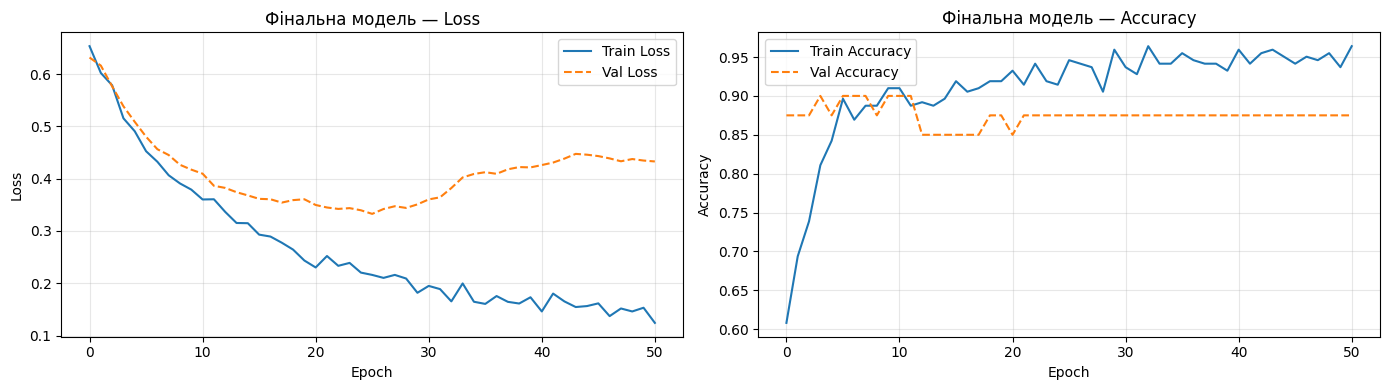

In [13]:
# Фінальна модель — DeepMLP + Adam + L2 + ReduceLROnPlateau + Early Stopping
print('═══ Фінальна модель ═══')
final_model = DeepMLP(INPUT_SIZE, dropout_rate=0.3)
final_optimizer = optim.Adam(final_model.parameters(), lr=0.001, weight_decay=1e-4)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    final_optimizer, mode='min', factor=0.5, patience=10
)

final_history = train_model(
    final_model, final_optimizer, criterion,
    train_loader, val_loader,
    num_epochs=200, patience=25,
    scheduler=final_scheduler,
    model_name='Final'
)

plot_history(final_history, title='Фінальна модель')

In [14]:
# Фінальна оцінка на тестовій вибірці
final_metrics = evaluate_model(final_model, X_test_t, y_test_t, label='Фінальна модель (Test)')


── Фінальна модель (Test) ──────────────────────────────────
  Accuracy : 89.36%
  F1 Score : 0.9367
  Precision: 0.9737
  Recall   : 0.9024
  ROC-AUC  : 0.9390
              precision    recall  f1-score   support

   No Cancer       0.56      0.83      0.67         6
      Cancer       0.97      0.90      0.94        41

    accuracy                           0.89        47
   macro avg       0.76      0.87      0.80        47
weighted avg       0.92      0.89      0.90        47



## 10. ROC-криві для всіх моделей

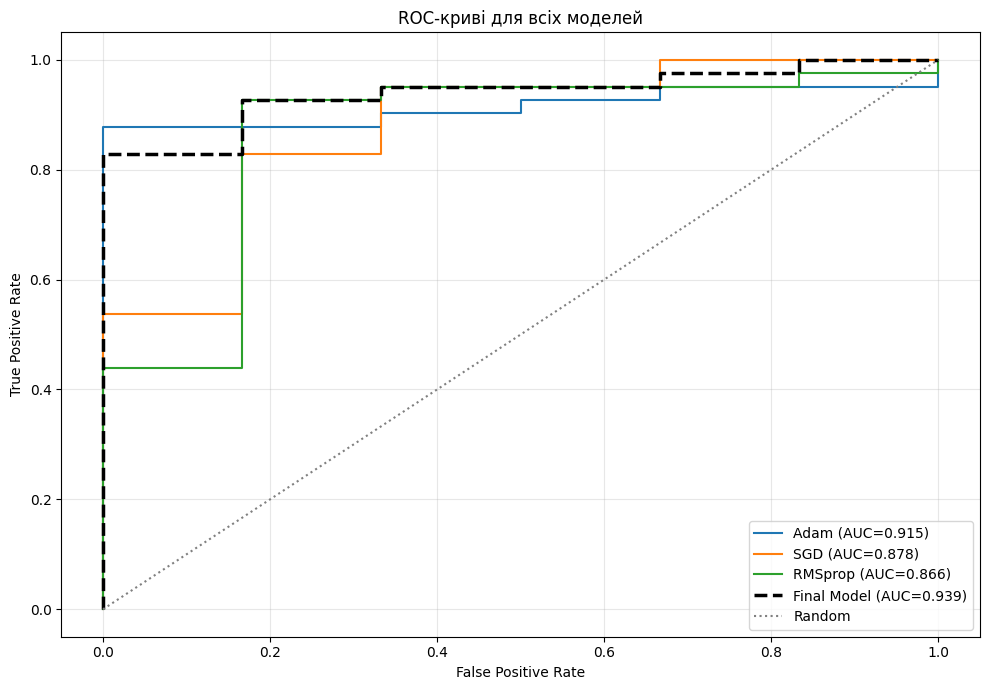

In [15]:
plt.figure(figsize=(10, 7))

# ROC оптимізаторів
for name, res in optimizer_results.items():
    m = res['metrics']
    plt.plot(m['fpr'], m['tpr'], label=f'{name} (AUC={m["auc"]:.3f})')

# ROC фінальної моделі
plt.plot(final_metrics['fpr'], final_metrics['tpr'],
         label=f'Final Model (AUC={final_metrics["auc"]:.3f})',
         linewidth=2.5, linestyle='--', color='black')

plt.plot([0,1], [0,1], color='gray', linestyle=':', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-криві для всіх моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Збереження моделі

In [16]:
# Збереження повного checkpoint
checkpoint = {
    'model_state_dict':     final_model.state_dict(),
    'optimizer_state_dict': final_optimizer.state_dict(),
    'input_size':           INPUT_SIZE,
    'test_accuracy':        final_metrics['acc'],
    'test_f1':              final_metrics['f1'],
    'test_auc':             final_metrics['auc'],
}

torch.save(checkpoint, 'lung_cancer_model.pt')
print('Модель збережена у файл: lung_cancer_model.pt')

# Перевірка завантаження
loaded = torch.load('lung_cancer_model.pt')
restore_model = DeepMLP(loaded['input_size'])
restore_model.load_state_dict(loaded['model_state_dict'])
print('Модель успішно завантажена!')
print(f'  Збережена точність: {loaded["test_accuracy"]*100:.2f}%')
print(f'  Збережений F1:      {loaded["test_f1"]:.4f}')
print(f'  Збережений AUC:     {loaded["test_auc"]:.4f}')

Модель збережена у файл: lung_cancer_model.pt
Модель успішно завантажена!
  Збережена точність: 89.36%
  Збережений F1:      0.9367
  Збережений AUC:     0.9390


## 12. Висновки

### Аналіз прикладів:
- **PyTorch MLP** використовує ReLU + Sigmoid, BCELoss, Adam. Простіший у розширенні.
- **NumPy XOR** — ручна реалізація backprop. Навчальна цінність, але не масштабується.
- **PyTorch є кращим**: автоgrad, GPU-підтримка, готові оптимізатори та шари.

### Фінальна архітектура (чому обрано):
- **4 приховані шари** (64→128→64→32→1): достатньо глибина для нелінійних залежностей у медичних даних.
- **ReLU**: відсутність затухання градієнта для позитивних значень → швидше навчання.
- **BatchNorm**: стабілізує навчання, прискорює збіжність, зменшує чутливість до LR.
- **Dropout (0.3)**: запобігає overfitting при відносно малому датасеті.
- **Adam + weight_decay=1e-4**: адаптивний LR + L2 регуляризація.
- **ReduceLROnPlateau**: автоматично зменшує LR при плато → краща точність.
- **Early Stopping (patience=25)**: зупиняє навчання до явного перенавчання.

### Вплив регуляризації:
- **L1**: заохочує розрідженість (більше нульових ваг), корисна для відбору ознак.
- **L2**: рівномірно зменшує ваги, плавніша поверхня функції втрат.
- **Dropout+BatchNorm**: найефективніша комбінація для глибоких мереж.

### Порівняння оптимізаторів:
- **Adam** зазвичай досягає найкращої точності завдяки адаптивному кроку.
- **SGD+momentum** може досягти кращого узагальнення при правильному налаштуванні LR.
- **RMSprop** — хороший баланс, особливо на шумних даних.

### Accuracy vs F1 при незбалансованих класах:
При значному дисбалансі класів accuracy може бути хибно завищена (модель прогнозує лише більший клас). F1, Precision, Recall та ROC-AUC є більш інформативними метриками для медичної класифікації.